# ResNet-18 on Noise RGB Residual Autocorrelation Maps

This notebook follows the same training and evaluation flow as the other image-classification notebooks, but the input representation is very different:

1. Uses the balanced `train_balanced`, `validation_balanced`, and `test_balanced` splits
2. Converts each image to grayscale
3. Computes a simple noise residual by subtracting a Gaussian-blurred version of the image
4. Computes the 2D autocorrelation map of that residual with an FFT-based implementation
5. Center-crops the autocorrelation map to `224x224`
6. Feeds the resulting single-channel map into a `ResNet-18`

This setup is aimed at emphasizing local periodic artifacts and structured noise patterns that may differ between real and AI-generated images.


In [4]:
import os
import time

import matplotlib.pylab as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights
from torchvision.transforms import functional as TF

# Use MPS on Apple Silicon when available, otherwise fall back to CPU.
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)


cpu


In [5]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_ROOT = PROJECT_ROOT / "output"
TRAIN_PATH = str(OUTPUT_ROOT / "train_balanced")
VAL_PATH = str(OUTPUT_ROOT / "validation_balanced")
TEST_PATH = str(OUTPUT_ROOT / "test_balanced")

WANDB_ENTITY = "william-em-watson-university-of-calgary-in-alberta"
WANDB_PROJECT = "ai-gen-image-detection"
WANDB_API_KEY = os.getenv("WANDB_API_KEY", "")


In [6]:
# Residual-autocorrelation preprocessing (RGB 3-channel version)
image_size = 224
gaussian_kernel_size = 5
gaussian_sigma = 1.0


class EnsureMinSize:
    def __init__(self, min_size=224, interpolation=transforms.InterpolationMode.BILINEAR):
        self.min_size = min_size
        self.interpolation = interpolation

    def __call__(self, image):
        width, height = image.size
        if width >= self.min_size and height >= self.min_size:
            return image

        scale = max(self.min_size / width, self.min_size / height)
        new_width = max(self.min_size, round(width * scale))
        new_height = max(self.min_size, round(height * scale))
        return TF.resize(image, (new_height, new_width), interpolation=self.interpolation)


class ResidualAutocorrelationTransformRGB:
    def __init__(self, image_size=224, gaussian_kernel_size=5, gaussian_sigma=1.0):
        self.image_size = image_size
        self.gaussian_kernel_size = gaussian_kernel_size
        self.gaussian_sigma = gaussian_sigma
        self.ensure_min_size = EnsureMinSize(min_size=image_size)

    def _autocorrelation_map(self, residual_tensor: torch.Tensor) -> torch.Tensor:
        # residual_tensor shape: [C, H, W]
        fft = torch.fft.fft2(residual_tensor, dim=(-2, -1))
        power = fft.abs() ** 2
        autocorr = torch.fft.ifft2(power, dim=(-2, -1)).real
        autocorr = torch.fft.fftshift(autocorr, dim=(-2, -1))
        return autocorr

    def __call__(self, image):
        image = self.ensure_min_size(image)
        image = TF.center_crop(image, [self.image_size, self.image_size])
        rgb_tensor = TF.to_tensor(image)  # [3, H, W]

        blurred = TF.gaussian_blur(
            rgb_tensor,
            kernel_size=[self.gaussian_kernel_size, self.gaussian_kernel_size],
            sigma=[self.gaussian_sigma, self.gaussian_sigma],
        )

        residual = rgb_tensor - blurred
        autocorr = self._autocorrelation_map(residual)

        # Per-channel normalization
        channel_means = autocorr.mean(dim=(-2, -1), keepdim=True)
        channel_stds = autocorr.std(dim=(-2, -1), keepdim=True).clamp_min(1e-6)
        autocorr = (autocorr - channel_means) / channel_stds
        return autocorr


transform = ResidualAutocorrelationTransformRGB(
    image_size=image_size,
    gaussian_kernel_size=gaussian_kernel_size,
    gaussian_sigma=gaussian_sigma,
)

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(VAL_PATH, transform=transform)
test_dataset = ImageFolder(TEST_PATH, transform=transform)

batch_size = 16
num_workers = 0

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


In [7]:
class_names = train_dataset.classes
print(class_names)
print('Train set:', len(train_dataset))
print('Val set:', len(val_dataset))
print('Test set:', len(test_dataset))



['ai_generated', 'real']
Train set: 13948
Val set: 2995
Test set: 5802


In [8]:
train_iterator = iter(trainloader)
train_batch = next(train_iterator)

In [9]:
print(train_batch[0].size())
print(train_batch[1].size())

torch.Size([16, 3, 224, 224])
torch.Size([16])


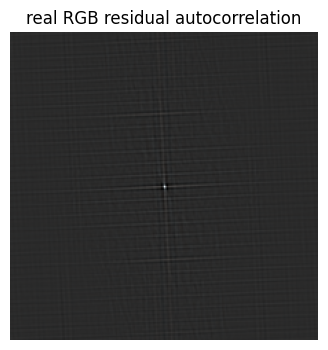

In [10]:
# Visualize one RGB residual-autocorrelation sample from the training set.
sample_map = train_batch[0][2].cpu()
sample_map = sample_map - sample_map.min()
sample_map = sample_map / sample_map.max().clamp_min(1e-6)
sample_map = sample_map.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(sample_map)
plt.title(f"{class_names[train_batch[1][2].item()]} RGB residual autocorrelation")
plt.axis('off')
plt.show()


In [11]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, use_pretrained=False, freeze_backbone=False):
        super().__init__()

        self.use_pretrained = use_pretrained
        self.freeze_backbone = freeze_backbone

        weights = ResNet18_Weights.DEFAULT if use_pretrained else None
        self.feature_extractor = models.resnet18(weights=weights)

        # Keep the original 3-channel conv1 because the RGB residual-autocorrelation input has 3 channels.
        if self.use_pretrained and self.freeze_backbone:
            for name, param in self.feature_extractor.named_parameters():
                if not name.startswith('fc.'):
                    param.requires_grad = False

        in_features = self.feature_extractor.fc.in_features
        self.feature_extractor.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.feature_extractor(x)


In [12]:
num_classes = len(class_names)
use_pretrained = False
freeze_backbone = False

# The RGB residual-autocorrelation input has 3 channels, but it is still not natural-image RGB,
# so scratch training is the safer default.
net = AiGenModel(
    num_classes=num_classes,
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
print(net)


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [13]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
weight_decay = 1e-4

trainable_params = [param for param in net.parameters() if param.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

input_representation = 'rgb_noise_residual_autocorrelation'
crop_strategy = 'center_crop_224x224'

USE_WANDB = True
wandb_run = None

wandb_config = {
    'train_path': TRAIN_PATH,
    'val_path': VAL_PATH,
    'test_path': TEST_PATH,
    'model_name': 'resnet18',
    'use_pretrained': use_pretrained,
    'freeze_backbone': freeze_backbone,
    'image_size': image_size,
    'gaussian_kernel_size': gaussian_kernel_size,
    'gaussian_sigma': gaussian_sigma,
    'input_representation': input_representation,
    'crop_strategy': crop_strategy,
    'batch_size': batch_size,
    'num_workers': num_workers,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'num_classes': num_classes,
    'device': str(device),
}

if USE_WANDB and wandb is not None:
    try:
        if WANDB_API_KEY:
            wandb.login(key=WANDB_API_KEY)
        else:
            print('WANDB_API_KEY is not set. Attempting to use existing W&B login session.')

        wandb_run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            config=wandb_config,
            mode='online',
            settings=wandb.Settings(start_method='thread'),
        )

        wandb.define_metric('epoch')
        wandb.define_metric('train_loss', step_metric='epoch')
        wandb.define_metric('train_acc', step_metric='epoch')
        wandb.define_metric('val_loss', step_metric='epoch')
        wandb.define_metric('val_acc', step_metric='epoch')
        wandb.define_metric('learning_rate', step_metric='epoch')
        wandb.define_metric('epoch_time_sec', step_metric='epoch')
        wandb.watch(net, criterion, log='all', log_freq=50)
        print('W&B enabled')
    except Exception as e:
        print('W&B failed to initialize; continuing without logging.')
        print(repr(e))
        wandb_run = None
else:
    print('W&B disabled or not installed.')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\toshi\_netrc
wandb: Currently logged in as: toshibiswas8 (toshibiswas8-university-of-calgary-in-alberta) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


W&B failed to initialize; continuing without logging.
ServicePollForTokenError('Failed to read port info after 30.0 seconds.')


In [14]:
# Tune nepochs and patience depending on how quickly validation loss plateaus.
nepochs = 10
PATH = './genai_resnet18_residual_autocorr_best.pth'

if wandb_run is not None:
    wandb.config.update({'nepochs': nepochs}, allow_val_change=True)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(nepochs):
    epoch_start_time = time.perf_counter()
    net.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_dataset)
    train_acc = train_correct / train_total

    net.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_dataset)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time_sec = time.perf_counter() - epoch_start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if wandb_run is not None:
        wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'learning_rate': current_lr,
        'epoch_time_sec': epoch_time_sec,
    })

    print(
        f'Epoch {epoch + 1}/{nepochs} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )

    if val_loss < best_val_loss:
        print('Saving best model')
        torch.save(net.state_dict(), PATH)
        best_val_loss = val_loss
        if wandb_run is not None:
            wandb.run.summary['best_val_loss'] = best_val_loss
            wandb.run.summary['best_epoch'] = epoch + 1

print('Finished training')


Epoch 1/10 | train_loss=0.5031 train_acc=0.7623 | val_loss=0.4671 val_acc=0.7806
Saving best model
Epoch 2/10 | train_loss=0.4424 train_acc=0.8040 | val_loss=0.4096 val_acc=0.8134
Saving best model
Epoch 3/10 | train_loss=0.4113 train_acc=0.8184 | val_loss=0.4285 val_acc=0.8053
Epoch 4/10 | train_loss=0.3837 train_acc=0.8332 | val_loss=0.3795 val_acc=0.8321
Saving best model
Epoch 5/10 | train_loss=0.3647 train_acc=0.8438 | val_loss=0.3724 val_acc=0.8351
Saving best model
Epoch 6/10 | train_loss=0.3443 train_acc=0.8548 | val_loss=0.3670 val_acc=0.8381
Saving best model
Epoch 7/10 | train_loss=0.3221 train_acc=0.8631 | val_loss=0.3512 val_acc=0.8508
Saving best model
Epoch 8/10 | train_loss=0.3080 train_acc=0.8730 | val_loss=0.3384 val_acc=0.8534
Saving best model
Epoch 9/10 | train_loss=0.2873 train_acc=0.8789 | val_loss=0.4045 val_acc=0.8280
Epoch 10/10 | train_loss=0.2592 train_acc=0.8937 | val_loss=0.3612 val_acc=0.8534
Finished training


In [15]:
# Load the best model before evaluating on the test set.
net = AiGenModel(
    num_classes=len(class_names),
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
net.load_state_dict(torch.load(PATH, map_location=device))
net.eval()


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [16]:
correct = 0
total = 0
test_loss = 0.0

test_start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_inference_time_sec = time.perf_counter() - test_start_time
test_loss = test_loss / len(test_dataset)
test_accuracy = correct / total

test_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_accuracy_percent': 100 * test_accuracy,
    'test_inference_time_sec': test_inference_time_sec,
}
if wandb_run is not None:
    wandb.log(test_metrics)
    for key, value in test_metrics.items():
        wandb.run.summary[key] = value

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {100 * test_accuracy:.2f}%')
print(f'Test inference time: {test_inference_time_sec:.2f}s')



Test loss: 0.8403
Test accuracy: 61.48%
Test inference time: 243.85s


In [17]:
# Optional: per-class accuracy helps us see whether one class is being ignored.
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            class_name = class_names[label.item()]
            class_total[class_name] += 1
            if label.item() == pred.item():
                class_correct[class_name] += 1

for class_name in class_names:
    accuracy = class_correct[class_name] / max(class_total[class_name], 1)
    print(f'{class_name}: {100 * accuracy:.2f}% ({class_correct[class_name]}/{class_total[class_name]})')
    if wandb_run is not None:
        wandb.log({f'test_accuracy_{class_name}': accuracy})
        wandb.run.summary[f'test_accuracy_{class_name}'] = accuracy



ai_generated: 62.20% (933/1500)
real: 61.23% (2634/4302)


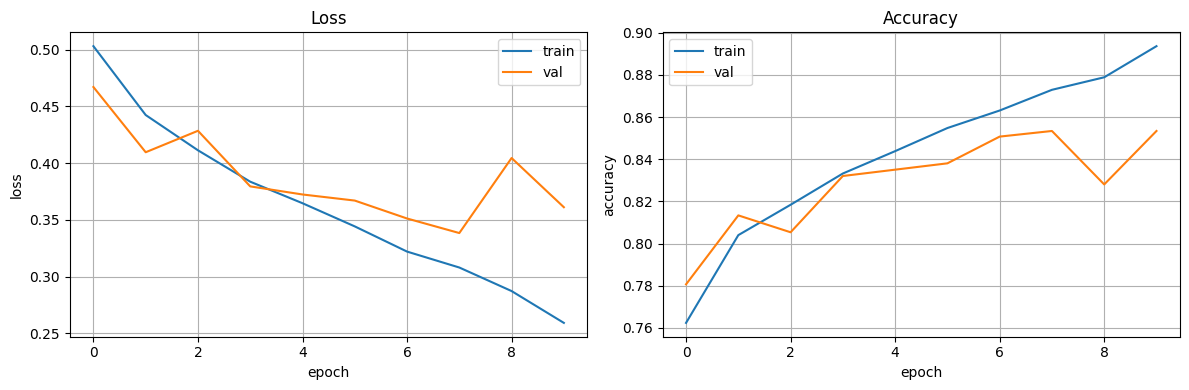

In [18]:
# Optional: visualize training curves.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# W&B already turns the logged epoch metrics into charts automatically.



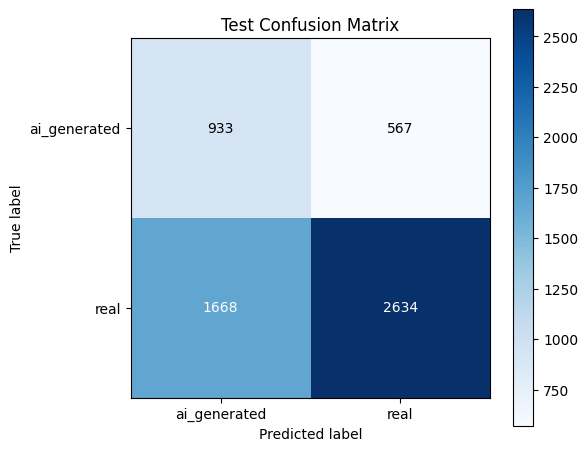

In [19]:
# Optional: plot the test-set confusion matrix.
confusion_matrix = torch.zeros((len(class_names), len(class_names)), dtype=torch.int64)

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[label.item(), pred.item()] += 1

cm = confusion_matrix.cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Test Confusion Matrix')

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()

if wandb_run is not None:
    wandb.finish()
